## 指标计算与练习模板

### 数据模块
1. 获取数据：标普500(^GSPC) 与 上证指数(000001.SS)历史收盘价
2. 保存/加载数据：保存为`close_SP_SS.csv`，便于后续复用
3. 价格可视化：绘制两者历史价格曲线

### 交易设定
4. 设定买入与卖出点：打印交易日期与价格

### 收益类指标
5. 计算累计收益率
6. 计算年化收益率（按实际持有天数，365天/年）
7. 计算超额收益率（标普500 - 上证指数）

### 风险与波动类指标
8. 计算日收益率（买卖区间内）
9. 计算波动率（年化，假设每年252个交易日）
10. 计算最大回撤

### 风险调整收益比率
11. 计算 Sharpe 比率（rf=0，基于日收益率年化）
12. 计算 Sortino 比率（MAR=0，基于下行波动年化）
13. 计算 Calmar 比率（年化收益率/最大回撤）

### 汇总与展示
14. 汇总输出：投资信息与指标对比表（上证指数 vs 标普500）

In [1]:
# 导入相关库
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 设置中文字体显示
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [3]:
# 1. 获取数据（标普500和上证指数）
symbols = ['^GSPC', '000001.SS']  # 标普500和上证指数
# data = yf.download(symbols,period="max")['Close']

In [4]:
# 2. 保存数据，便于后续使用
# data.to_csv('close_SP_SS.csv')
data = pd.read_csv('close_SP_SS.csv', index_col=0, parse_dates=True)
data.head()

,000001.SS,^GSPC
Date,,
1927-12-30,NaN,17.660000
1928-01-03,NaN,17.760000
1928-01-04,NaN,17.719999
1928-01-05,NaN,17.549999
1928-01-06,NaN,17.660000


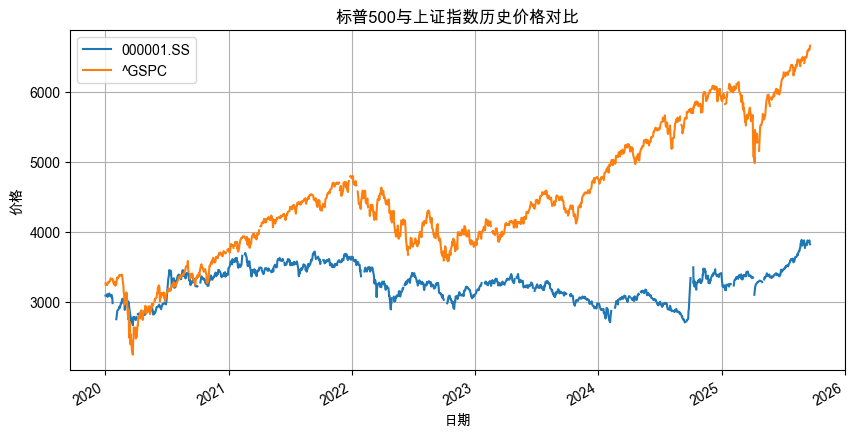

In [5]:
# 3. 可视化价格曲线
data['2020':].plot(title="标普500与上证指数历史价格对比", xlabel="日期", ylabel="价格", grid=True, figsize=[10,5])
plt.legend([symbols[1], symbols[0]])

In [6]:
# 4. 定义买入卖出点（选择特定的一点）
buy_date = '2020-09-02'  # 假设买入点
sell_date = '2025-09-02'  # 假设卖出点

buy_price_sp500 = data.loc[buy_date, '^GSPC']
sell_price_sp500 = data.loc[sell_date, '^GSPC']

buy_price_sh = data.loc[buy_date, '000001.SS']
sell_price_sh = data.loc[sell_date, '000001.SS']

# 打印买入、卖出时间和价格
print(f"买入点: {buy_date}, 标普500价格: {buy_price_sp500}, 上证指数价格: {buy_price_sh}")
print(f"卖出点: {sell_date}, 标普500价格: {sell_price_sp500}, 上证指数价格: {sell_price_sh}")

买入点: 2020-09-02, 标普500价格: 3580.840087890625, 上证指数价格: 3404.802001953125
卖出点: 2025-09-02, 标普500价格: 6415.5400390625, 上证指数价格: 3858.133056640625


In [7]:
# 5. 计算累计收益率
cumulative_return_sp500 = (sell_price_sp500 - buy_price_sp500) / buy_price_sp500
cumulative_return_sh = (sell_price_sh - buy_price_sh) / buy_price_sh
cumulative_return_sp500, cumulative_return_sh

(0.7916298638294454, 0.13314461587706183)

In [8]:
# 6. 计算年化收益率：1/T，T为年数，T = days/252 -> 1/T = 252 / days
anual_days = 365
days_held = (pd.to_datetime(sell_date) - pd.to_datetime(buy_date)).days
annualized_return_sp500 = (1 + cumulative_return_sp500) ** (anual_days / days_held) - 1
annualized_return_sh = (1 + cumulative_return_sh) ** (anual_days / days_held) - 1
days_held, annualized_return_sp500, annualized_return_sh

(1826, 0.12362636374168856, 0.02530038888209063)

In [9]:
# 7. 计算超额收益率（相对于上证指数）
excess_return_sp500 = cumulative_return_sp500 - cumulative_return_sh
excess_return_sp500

0.6584852479523836

In [10]:
# 8. 计算波动率
trading_days = 252

# 选取买卖区间的价格数据
price_sp500 = data.loc[buy_date:sell_date, '^GSPC'].dropna()
price_sh = data.loc[buy_date:sell_date, '000001.SS'].dropna()

# 日收益率
daily_ret_sp500 = price_sp500.pct_change().dropna()
daily_ret_sh = price_sh.pct_change().dropna()

price_sp500, daily_ret_sp500

(Date
 2020-09-02    3580.840088
 2020-09-03    3455.060059
 2020-09-04    3426.959961
 2020-09-08    3331.840088
 2020-09-09    3398.959961
                  ...     
 2025-08-26    6465.939941
 2025-08-27    6481.399902
 2025-08-28    6501.859863
 2025-08-29    6460.259766
 2025-09-02    6415.540039
 Name: ^GSPC, Length: 1255, dtype: float64,
 Date
 2020-09-03   -0.035126
 2020-09-04   -0.008133
 2020-09-08   -0.027756
 2020-09-09    0.020145
 2020-09-10   -0.017585
                 ...   
 2025-08-26    0.004134
 2025-08-27    0.002391
 2025-08-28    0.003157
 2025-08-29   -0.006398
 2025-09-02   -0.006922
 Name: ^GSPC, Length: 1254, dtype: float64)

In [11]:
# 波动率（年化）
vol_sp500 = daily_ret_sp500.std() * np.sqrt(trading_days)
vol_sh = daily_ret_sh.std() * np.sqrt(trading_days)

vol_sp500, vol_sh
# daily_ret_sp500.std(),daily_ret_sh.std()

(0.17384465710482983, 0.15857521285190196)

In [12]:
# 9. 计算最大回撤
rolling_max_sp500 = price_sp500.cummax()
rolling_max_sh = price_sh.cummax()

drawdown_sp500 = (price_sp500 - rolling_max_sp500) / rolling_max_sp500
drawdown_sh = (price_sh - rolling_max_sh) / rolling_max_sh

max_drawdown_sp500 = drawdown_sp500.min()
max_drawdown_sh = drawdown_sh.min()

max_drawdown_sp500, max_drawdown_sh

(-0.254250966192304, -0.27270097638636376)

In [18]:
# 10. 计算 Sharpe（rf=0.02）
rf = 0.02
sharpe_sp500 = (annualized_return_sp500 - rf) / vol_sp500
sharpe_sh = (annualized_return_sh - rf) / vol_sh

sharpe_sp500, sharpe_sh

(0.5960859854277889, 0.03342507814913556)

In [21]:
# 11. 计算 Sortino（MAR=0）
downside_sp500 = daily_ret_sp500[daily_ret_sp500 < 0]
downside_sh = daily_ret_sh[daily_ret_sh < 0]

down_annual_vol_sp500 = downside_sp500.std() * np.sqrt(trading_days)
down_annual_vol_sh = downside_sh.std() * np.sqrt(trading_days)

sortino_sp500 = (annualized_return_sp500 - rf) / down_annual_vol_sp500
sortino_sh = (annualized_return_sh - rf) / down_annual_vol_sh

sortino_sp500, sortino_sh

(0.8210208648100332, 0.04537056862448809)

In [19]:
# 12. 计算 Calmar（使用上面计算的年化收益率与最大回撤）
calmar_sp500 = (annualized_return_sp500 / abs(max_drawdown_sp500))
calmar_sh = (annualized_return_sh / abs(max_drawdown_sh))

calmar_sp500, calmar_sh

(0.4862375376311575, 0.0927770381219499)

In [22]:
# 13. 打印投资回报（结构化输出）
years_held = days_held / anual_days  # 将持有天数转为年数

# 顶部投资信息
print("投资信息:")
print(f"买入日期: {buy_date}  卖出日期: {sell_date}")
print(f"持有天数: {days_held}天  持有年数: {years_held:.2f}年")

# 构建指标表（列：上证指数、标普500；行：指标）
metrics = {
    '累计收益率': [cumulative_return_sh, cumulative_return_sp500],
    '年化收益率': [annualized_return_sh, annualized_return_sp500],
    '年化波动率': [vol_sh, vol_sp500],
    '最大回撤': [max_drawdown_sh, max_drawdown_sp500],
    'Sharpe': [sharpe_sh, sharpe_sp500],
    'Sortino': [sortino_sh, sortino_sp500],
    'Calmar': [calmar_sh, calmar_sp500],
    '超额收益率(标普-上证)': [np.nan, excess_return_sp500],
}
metrics_df = pd.DataFrame(metrics, index=['上证指数', '标普500']).T
metrics_df.index.name = '指标'
metrics_df = metrics_df.reset_index()

# 按需格式化（百分比与比率）
# 注意：此处将“波动率”也作为百分比格式化为两位小数
pct_rows = ['累计收益率', '年化收益率', '年化波动率', '最大回撤', '超额收益率(标普-上证)']
ratio_rows = ['Sharpe', 'Sortino', 'Calmar']

def fmt_pct(x):
    return '-' if pd.isna(x) else f"{x:.2%}"

def fmt_num(x):
    return '-' if pd.isna(x) else f"{x:.2f}"

formatted = metrics_df.copy()
# 先把目标列转换为object，避免后续写入字符串触发dtype警告
formatted = formatted.astype({'上证指数': 'object', '标普500': 'object'})

pct_mask = formatted['指标'].isin(pct_rows)
ratio_mask = formatted['指标'].isin(ratio_rows)

# 元素级格式化：百分比与比率
formatted.loc[pct_mask, ['上证指数', '标普500']] = \
    formatted.loc[pct_mask, ['上证指数', '标普500']].applymap(fmt_pct)
formatted.loc[ratio_mask, ['上证指数', '标普500']] = \
    formatted.loc[ratio_mask, ['上证指数', '标普500']].applymap(fmt_num)

# 对齐输出：将数值列右对齐以便在控制台打印时排齐
for col in ['上证指数', '标普500']:
    formatted[col] = formatted[col].astype(str)
    max_width = formatted[col].str.len().max()
    formatted[col] = formatted[col].str.rjust(max_width)

print("指标对比表（上证指数 vs 标普500）:")
print(formatted.to_string(index=False))

投资信息:
买入日期: 2020-09-02  卖出日期: 2025-09-02
持有天数: 1826天  持有年数: 5.00年
指标对比表（上证指数 vs 标普500）:
          指标    上证指数   标普500
       累计收益率  13.31%  79.16%
       年化收益率   2.53%  12.36%
       年化波动率  15.86%  17.38%
        最大回撤 -27.27% -25.43%
      Sharpe    0.03    0.60
     Sortino    0.05    0.82
      Calmar    0.09    0.49
超额收益率(标普-上证)       -  65.85%
